In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Create SQLite database
conn = sqlite3.connect('shopfast_supply_chain.db')

# Load all 9 CSV files into the database
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

# Save all tables into SQLite database
orders.to_sql('orders', conn, if_exists='replace', index=False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
sellers.to_sql('sellers', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
reviews.to_sql('reviews', conn, if_exists='replace', index=False)
geolocation.to_sql('geolocation', conn, if_exists='replace', index=False)
category_translation.to_sql('category_translation', conn, if_exists='replace', index=False)

print("=== DATABASE CREATED SUCCESSFULLY ===")
print(f"Orders: {len(orders):,} rows")
print(f"Order items: {len(order_items):,} rows")
print(f"Sellers: {len(sellers):,} rows")
print(f"Products: {len(products):,} rows")
print(f"Customers: {len(customers):,} rows")
print(f"Payments: {len(payments):,} rows")
print(f"Reviews: {len(reviews):,} rows")
print(f"Geolocation: {len(geolocation):,} rows")
print(f"Category translation: {len(category_translation):,} rows")

=== DATABASE CREATED SUCCESSFULLY ===
Orders: 99,441 rows
Order items: 112,650 rows
Sellers: 3,095 rows
Products: 32,951 rows
Customers: 99,441 rows
Payments: 103,886 rows
Reviews: 99,224 rows
Geolocation: 1,000,163 rows
Category translation: 71 rows


In [3]:
# Verify all tables loaded correctly
query = """
SELECT 'orders' as table_name, COUNT(*) as row_count FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL
SELECT 'sellers', COUNT(*) FROM sellers
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL
SELECT 'customers', COUNT(*) FROM customers
UNION ALL
SELECT 'payments', COUNT(*) FROM payments
UNION ALL
SELECT 'reviews', COUNT(*) FROM reviews
"""

result = pd.read_sql_query(query, conn)
print(result)

    table_name  row_count
0       orders      99441
1  order_items     112650
2      sellers       3095
3     products      32951
4    customers      99441
5     payments     103886
6      reviews      99224


In [4]:
# KPI-01: Average fulfillment time in days
query = """
SELECT 
    ROUND(AVG(
        JULIANDAY(order_delivered_customer_date) - 
        JULIANDAY(order_purchase_timestamp)
    ), 2) as avg_fulfillment_days,
    
    MIN(ROUND(
        JULIANDAY(order_delivered_customer_date) - 
        JULIANDAY(order_purchase_timestamp)
    , 2)) as min_days,
    
    MAX(ROUND(
        JULIANDAY(order_delivered_customer_date) - 
        JULIANDAY(order_purchase_timestamp)
    , 2)) as max_days,
    
    COUNT(*) as total_delivered_orders

FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
"""

result = pd.read_sql_query(query, conn)
print("=== KPI-01: AVERAGE FULFILLMENT TIME ===")
print(result)

=== KPI-01: AVERAGE FULFILLMENT TIME ===
   avg_fulfillment_days  min_days  max_days  total_delivered_orders
0                 12.56      0.53    209.63                   96470


In [5]:
# KPI-02: OTIF Rate
query = """
SELECT
    COUNT(*) as total_orders,
    
    SUM(CASE 
        WHEN order_delivered_customer_date <= order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) as on_time_orders,
    
    ROUND(100.0 * SUM(CASE 
        WHEN order_delivered_customer_date <= order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) / COUNT(*), 2) as otif_rate_pct,

    ROUND(100.0 * SUM(CASE 
        WHEN order_delivered_customer_date > order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) / COUNT(*), 2) as late_delivery_pct

FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
AND order_estimated_delivery_date IS NOT NULL
"""

result = pd.read_sql_query(query, conn)
print("=== KPI-02: OTIF RATE ===")
print(result)

=== KPI-02: OTIF RATE ===
   total_orders  on_time_orders  otif_rate_pct  late_delivery_pct
0         96470           88644          91.89               8.11


In [6]:
# KPI-03: Order Cancellation Rate
query = """
SELECT
    COUNT(*) as total_orders,
    
    SUM(CASE WHEN order_status = 'canceled' THEN 1 ELSE 0 END) as cancelled_orders,
    
    ROUND(100.0 * SUM(CASE 
        WHEN order_status = 'canceled' THEN 1 ELSE 0 
    END) / COUNT(*), 2) as cancellation_rate_pct,

    SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) as delivered_orders,
    
    SUM(CASE WHEN order_status = 'shipped' THEN 1 ELSE 0 END) as shipped_orders

FROM orders
"""

result = pd.read_sql_query(query, conn)
print("=== KPI-03: ORDER CANCELLATION RATE ===")
print(result)

=== KPI-03: ORDER CANCELLATION RATE ===
   total_orders  cancelled_orders  cancellation_rate_pct  delivered_orders  \
0         99441               625                   0.63             96478   

   shipped_orders  
0            1107  


In [3]:
# KPI-04 & 05: Delay rate by product category AND seller
query = """
SELECT 
    ct.product_category_name_english as category,
    COUNT(o.order_id) as total_orders,
    
    SUM(CASE 
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) as late_orders,
    
    ROUND(100.0 * SUM(CASE 
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) / COUNT(o.order_id), 2) as delay_rate_pct,
    
    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) - 
        JULIANDAY(o.order_purchase_timestamp)
    ), 2) as avg_fulfillment_days

FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY ct.product_category_name_english
ORDER BY delay_rate_pct DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
print("=== KPI-04: TOP 10 DELAY-PRONE CATEGORIES ===")
print(result.to_string())

=== KPI-04: TOP 10 DELAY-PRONE CATEGORIES ===
                            category  total_orders  late_orders  delay_rate_pct  avg_fulfillment_days
0                     home_comfort_2            30            5           16.67                 14.57
1  furniture_mattress_and_upholstery            37            5           13.51                 14.43
2                              audio           362           46           12.71                 13.32
3            fashion_underwear_beach           127           16           12.60                 13.71
4                 christmas_supplies           150           18           12.00                 15.74
5                    books_technical           263           29           11.03                 10.65
6                       home_confort           429           44           10.26                 13.53
7          construction_tools_lights           301           30            9.97                  9.72
8                               food

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Reconnect to database
conn = sqlite3.connect('shopfast_supply_chain.db')
print("All libraries and database reconnected!")

All libraries and database reconnected!


In [3]:
# KPI-05: Top 10 worst sellers by delay rate (simplified)
query = """
SELECT 
    s.seller_id,
    s.seller_city,
    s.seller_state,
    COUNT(o.order_id) as total_orders,
    
    SUM(CASE 
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) as late_orders,
    
    ROUND(100.0 * SUM(CASE 
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) / COUNT(o.order_id), 2) as delay_rate_pct,

    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) - 
        JULIANDAY(o.order_purchase_timestamp)
    ), 2) as avg_fulfillment_days

FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN sellers s ON oi.seller_id = s.seller_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY s.seller_id, s.seller_city, s.seller_state
HAVING total_orders >= 50
ORDER BY delay_rate_pct DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
print("=== KPI-05: TOP 10 WORST SELLERS BY DELAY RATE ===")
print(result.to_string())

=== KPI-05: TOP 10 WORST SELLERS BY DELAY RATE ===
                          seller_id     seller_city seller_state  total_orders  late_orders  delay_rate_pct  avg_fulfillment_days
0  54965bbe3e4f07ae045b90b0b8541f52   foz do iguacu           PR            81           26           32.10                 26.73
1  2a1348e9addc1af5aaa619b1a3679d6b  belo horizonte           MG            51           15           29.41                 27.20
2  6039e27294dc75811c0d8a39069f52c0          osasco           SP            74           19           25.68                 17.98
3  a49928bcdf77c55c6d6e05e09a9b4ca5       sao paulo           SP           104           26           25.00                 16.94
4  602044f2c16190c2c6e45eb35c2e21cb        ibitinga           SP            55           13           23.64                 15.83
5  06a2c3af7b3aee5d69171b0e14f0ee87        sao luis           MA           402           95           23.63                 17.74
6  beadbee30901a7f61d031b6b686095ad    

In [4]:
# KPI-06: Revenue at risk
query = """
SELECT
    COUNT(o.order_id) as cancelled_orders,
    ROUND(AVG(p.payment_value), 2) as avg_order_value,
    ROUND(SUM(p.payment_value), 2) as total_revenue_lost,
    ROUND(SUM(p.payment_value) * 12, 2) as projected_annual_loss

FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'canceled'
"""

result = pd.read_sql_query(query, conn)
print("=== KPI-06: REVENUE AT RISK ===")
print(result.to_string())

=== KPI-06: REVENUE AT RISK ===
   cancelled_orders  avg_order_value  total_revenue_lost  projected_annual_loss
0               664           215.75            143255.6              1719067.2


In [5]:
# Build final dashboard dataset
query = """
SELECT 
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    
    ROUND(JULIANDAY(o.order_delivered_customer_date) - 
          JULIANDAY(o.order_purchase_timestamp), 2) as fulfillment_days,
    
    CASE 
        WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END as is_on_time,
    
    CASE 
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END as is_late,

    s.seller_id,
    s.seller_city,
    s.seller_state,
    
    ct.product_category_name_english as category,
    
    p.payment_value,
    c.customer_city,
    c.customer_state

FROM orders o
LEFT JOIN order_items oi ON o.order_id = oi.order_id
LEFT JOIN sellers s ON oi.seller_id = s.seller_id
LEFT JOIN products pr ON oi.product_id = pr.product_id
LEFT JOIN category_translation ct ON pr.product_category_name = ct.product_category_name
LEFT JOIN payments p ON o.order_id = p.order_id
LEFT JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
"""

df_dashboard = pd.read_sql_query(query, conn)
df_dashboard.to_csv('supply_chain_dashboard.csv', index=False)

print(f"Dashboard dataset saved!")
print(f"Total rows: {len(df_dashboard):,}")
print(f"Columns: {list(df_dashboard.columns)}")

Dashboard dataset saved!
Total rows: 115,030
Columns: ['order_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'fulfillment_days', 'is_on_time', 'is_late', 'seller_id', 'seller_city', 'seller_state', 'category', 'payment_value', 'customer_city', 'customer_state']


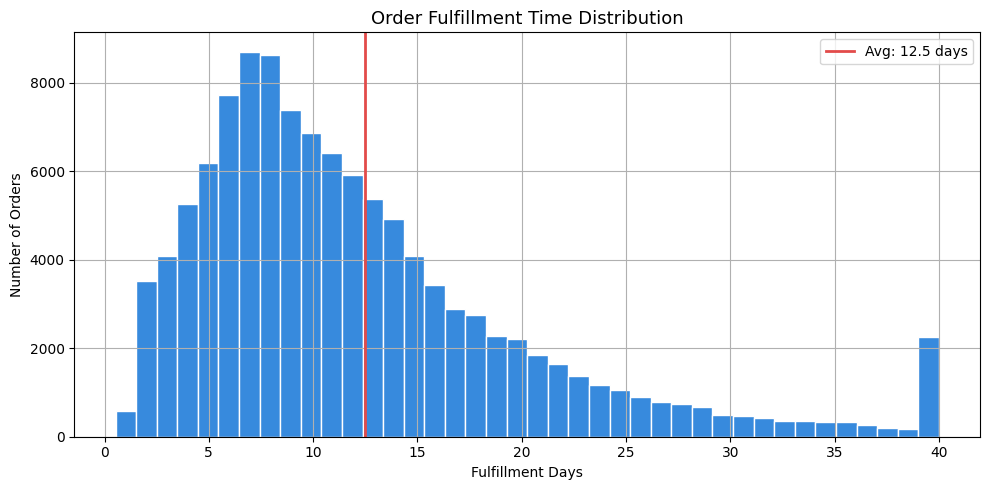

In [6]:
# Chart 1 — Fulfillment time distribution
plt.figure(figsize=(10, 5))
df_dashboard['fulfillment_days'].clip(0, 40).hist(
    bins=40, color='#378ADD', edgecolor='white'
)
plt.axvline(x=df_dashboard['fulfillment_days'].mean(), 
            color='#E24B4A', linewidth=2, 
            label=f"Avg: {df_dashboard['fulfillment_days'].mean():.1f} days")
plt.title('Order Fulfillment Time Distribution', fontsize=13)
plt.xlabel('Fulfillment Days')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig('chart1_fulfillment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

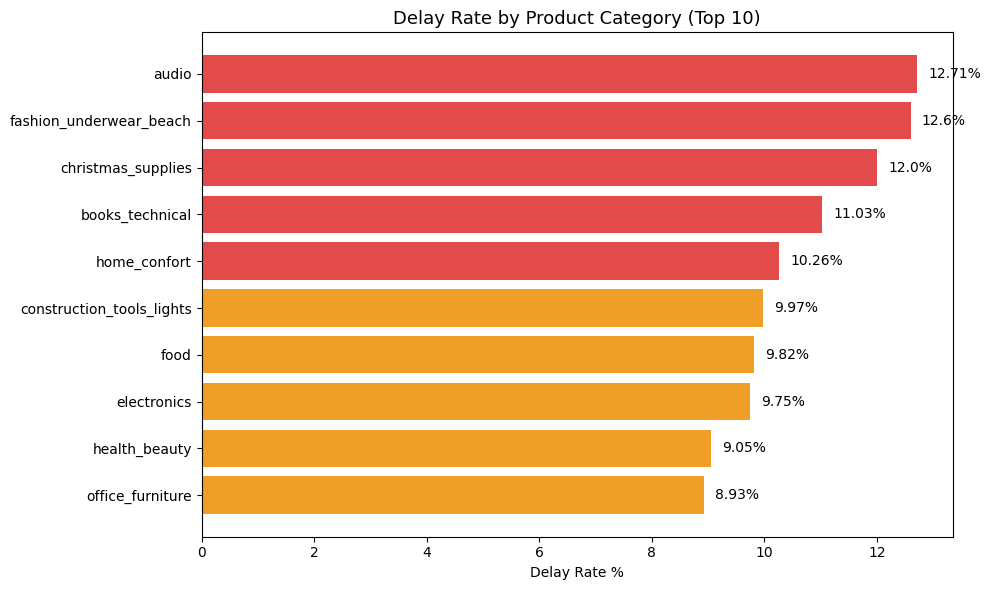

In [3]:
# Chart 2 — Delay rate by top 10 categories
query = """
SELECT 
    ct.product_category_name_english as category,
    COUNT(o.order_id) as total_orders,
    ROUND(100.0 * SUM(CASE 
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) / COUNT(o.order_id), 2) as delay_rate_pct
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY category
HAVING total_orders >= 100
ORDER BY delay_rate_pct DESC
LIMIT 10
"""

df_cat = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
colors = ['#E24B4A' if x > 10 else '#EF9F27' if x > 7 else '#3B6D11' for x in df_cat['delay_rate_pct']]
bars = plt.barh(df_cat['category'], df_cat['delay_rate_pct'], color=colors)
plt.title('Delay Rate by Product Category (Top 10)', fontsize=13)
plt.xlabel('Delay Rate %')
plt.gca().invert_yaxis()

for bar, val in zip(bars, df_cat['delay_rate_pct']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart2_category_delays.png', dpi=150, bbox_inches='tight')
plt.show()

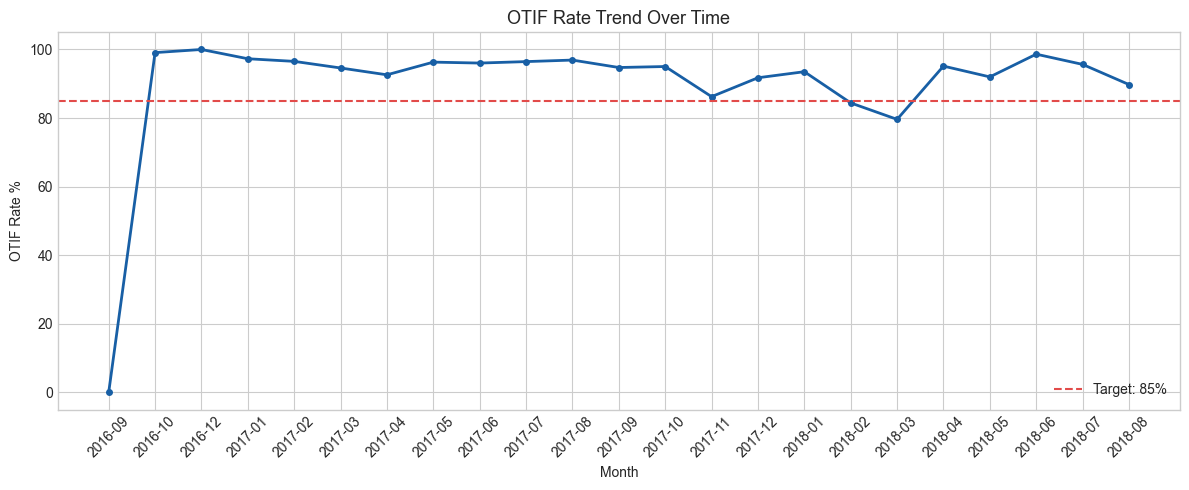

In [6]:
# Chart 3 — OTIF rate trend over time
df_dashboard['order_purchase_timestamp'] = pd.to_datetime(df_dashboard['order_purchase_timestamp'])
df_dashboard['month'] = df_dashboard['order_purchase_timestamp'].dt.to_period('M')

otif_trend = df_dashboard.groupby('month')['is_on_time'].mean().reset_index()
otif_trend['month'] = otif_trend['month'].astype(str)
otif_trend['otif_pct'] = otif_trend['is_on_time'] * 100

plt.figure(figsize=(12, 5))
plt.plot(otif_trend['month'], otif_trend['otif_pct'], 
         color='#185FA5', linewidth=2, marker='o', markersize=4)
plt.axhline(y=85, color='#E24B4A', linewidth=1.5, 
            linestyle='--', label='Target: 85%')
plt.title('OTIF Rate Trend Over Time', fontsize=13)
plt.ylabel('OTIF Rate %')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('chart3_otif_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Reconnect to database
conn = sqlite3.connect('shopfast_supply_chain.db')

# Reload dashboard dataset
df_dashboard = pd.read_csv('supply_chain_dashboard.csv')

print(f"Reloaded! Rows: {len(df_dashboard):,}")
print("Ready to continue!")

Reloaded! Rows: 115,030
Ready to continue!


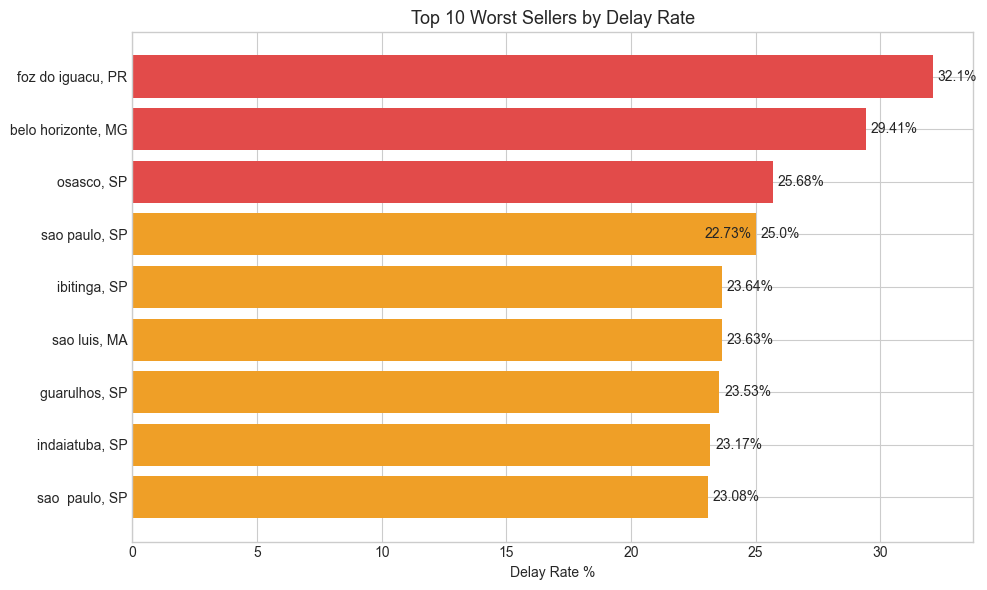

In [7]:
# Chart 4 — Top 10 worst sellers by delay rate
query = """
SELECT 
    s.seller_city || ', ' || s.seller_state as seller_location,
    COUNT(o.order_id) as total_orders,
    ROUND(100.0 * SUM(CASE 
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 
    END) / COUNT(o.order_id), 2) as delay_rate_pct
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN sellers s ON oi.seller_id = s.seller_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY s.seller_id, s.seller_city, s.seller_state
HAVING total_orders >= 50
ORDER BY delay_rate_pct DESC
LIMIT 10
"""

df_sellers = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
colors = ['#E24B4A' if x > 25 else '#EF9F27' if x > 15 else '#3B6D11' for x in df_sellers['delay_rate_pct']]
bars = plt.barh(df_sellers['seller_location'], df_sellers['delay_rate_pct'], color=colors)
plt.title('Top 10 Worst Sellers by Delay Rate', fontsize=13)
plt.xlabel('Delay Rate %')
plt.gca().invert_yaxis()

for bar, val in zip(bars, df_sellers['delay_rate_pct']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart4_seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()